# 02 · Pronóstico de demanda con validación temporal

**Objetivo:** pronosticar la demanda diaria de los próximos 28 días para cada producto x sede, y demostrar con métricas si el Machine Learning mejora a un modelo base simple.

Contenido:
1. Ingeniería de variables sin fuga de información.
2. Validación temporal (backtesting con origen móvil).
3. Modelos base vs. Machine Learning (métricas MAE, MAPE, WAPE, sesgo).
4. Interpretación: importancia de variables y análisis de errores.
5. Pronóstico final con intervalo de predicción.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Permite importar el paquete del proyecto (src/healthsupply) desde el notebook.
sys.path.insert(0, str(Path.cwd().parent / "src"))
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

from healthsupply.data_loading import cargar_todo
from healthsupply.config import DATA_PROCESSED
from healthsupply import figures  # aplica el estilo de gráficos del proyecto
from healthsupply import forecasting as fc
from healthsupply.metrics import calcular_metricas, metricas_por_grupo
from IPython.display import Image

## 1. Panel de datos e ingeniería de variables

Pasamos la demanda a un **panel**: una fila por fecha x producto x sede con la columna objetivo `y`.

In [2]:
t = cargar_todo()
panel = fc.preparar_panel(t["fact_demanda"])
features = fc.construir_features(panel)
print(f"{panel[['producto_id', 'ubicacion_id']].drop_duplicates().shape[0]} series · {len(panel):,} filas")
print("Variables del modelo:", fc.FEATURES)

75 series · 82,200 filas
Variables del modelo: ['dia_semana', 'mes', 'dia_mes', 'semana_anio', 'dia_anio', 'fin_de_semana', 'lag_28', 'lag_35', 'lag_42', 'lag_49', 'lag_364', 'prom_dia_semana_4s', 'media_movil_7', 'media_movil_28', 'media_movil_91', 'desv_movil_28', 'producto_cod', 'ubicacion_cod']


In [3]:
cols = ["fecha", "y", "dia_semana", "lag_28", "lag_35", "prom_dia_semana_4s", "media_movil_28", "lag_364"]
features[(features["producto_id"] == "MED-001") & (features["ubicacion_id"] == "LOC-001")][cols].iloc[400:410]

,fecha,y,dia_semana,lag_28,lag_35,prom_dia_semana_4s,media_movil_28,lag_364
400,2024-02-05,58.0,0,89.0,78.0,76.25,58.892857,77.0
401,2024-02-06,78.0,1,67.0,81.0,65.25,59.142857,67.0
402,2024-02-07,69.0,2,90.0,80.0,69.75,60.500000,63.0
403,2024-02-08,69.0,3,71.0,91.0,70.75,60.714286,71.0
404,2024-02-09,67.0,4,58.0,69.0,61.50,60.785714,50.0
405,2024-02-10,52.0,5,63.0,62.0,53.50,61.821429,56.0
406,2024-02-11,38.0,6,41.0,40.0,38.25,62.178571,42.0
407,2024-02-12,57.0,0,68.0,89.0,76.75,62.250000,65.0
408,2024-02-13,63.0,1,72.0,67.0,68.25,62.678571,72.0
409,2024-02-14,87.0,2,77.0,90.0,75.50,63.500000,59.0


### ¿Por qué todos los rezagos son de 28 días o más?

Supongamos que hoy es 31-dic y pronosticamos el 28-ene (28 días adelante). Lo más reciente que sabremos de "la demanda de ese día hace X días" es la de hace 28 días (31-dic). Si el modelo usara `lag_1` (ayer) durante el entrenamiento, aprendería a depender de un dato que **no existirá** al pronosticar → métricas infladas en el laboratorio y mal desempeño en producción. Esto se llama **fuga de información (data leakage)**.

Verificación rápida: el `lag_28` de una fila debe ser la `y` de 28 días antes.

In [4]:
serie = features[(features["producto_id"] == "MED-001") & (features["ubicacion_id"] == "LOC-001")].reset_index(drop=True)
assert (serie["lag_28"].iloc[28:].values == serie["y"].iloc[:-28].values).all()
print("OK: lag_28 corresponde exactamente a la demanda de hace 28 días")

OK: lag_28 corresponde exactamente a la demanda de hace 28 días


## 2. Validación temporal (backtesting)

En series de tiempo **no** se usa `train_test_split` aleatorio (mezclaría futuro con pasado). Se simula el uso real: entrenar con el pasado y evaluar en el periodo siguiente, moviendo el origen:

```
fold 1  [======== entrenamiento ========][test 28d]
fold 2  [=========== entrenamiento ==========][test 28d]
fold 3  [============== entrenamiento =============][test 28d]
fold 4  [================= entrenamiento ================][test 28d]  <- termina 31-dic-2025
```

In [5]:
for i, origen in enumerate(fc.origenes_backtest(panel["fecha"].max()), 1):
    print(f"fold {i}: entrena hasta {origen.date()} -> evalúa {(origen + pd.Timedelta(days=1)).date()} "
          f"a {(origen + pd.Timedelta(days=28)).date()}")

fold 1: entrena hasta 2025-09-10 -> evalúa 2025-09-11 a 2025-10-08
fold 2: entrena hasta 2025-10-08 -> evalúa 2025-10-09 a 2025-11-05
fold 3: entrena hasta 2025-11-05 -> evalúa 2025-11-06 a 2025-12-03
fold 4: entrena hasta 2025-12-03 -> evalúa 2025-12-04 a 2025-12-31


### Demostración con un fold

Para que el notebook sea rápido, aquí ejecutamos **solo el último fold** paso a paso. El backtest completo (4 folds x 5 modelos) lo corre `scripts/run_pipeline.py` y guarda los resultados en `data/processed/`.

In [6]:
origen = fc.origenes_backtest(panel["fecha"].max())[-1]
fechas_test = pd.date_range(origen + pd.Timedelta(days=1), periods=28)
historia = panel[panel["fecha"] <= origen]
real = panel[panel["fecha"].isin(fechas_test)]

resultados = {}
# Modelos base: solo miran la historia anterior al origen.
for metodo in fc.MODELOS_BASE:
    pred = real.merge(fc.pronostico_base(historia, fechas_test, metodo), on=["fecha", "producto_id", "ubicacion_id"])
    resultados[metodo] = calcular_metricas(pred["y"], pred["yhat"])

# Modelo de ML: se entrena con las filas anteriores al origen.
train = fc._entrenables(features[features["fecha"] <= origen])
test = features[features["fecha"].isin(fechas_test)]
modelo = fc.crear_modelos_ml()["HistGradientBoosting"].fit(train[fc.FEATURES], train["y"])
resultados["HistGradientBoosting"] = calcular_metricas(test["y"], modelo.predict(test[fc.FEATURES]))

pd.DataFrame(resultados).T.round(2).sort_values("WAPE")

,MAE,MAPE,WAPE,Sesgo_pct,RMSE
HistGradientBoosting,2.20,11.15,11.20,-4.57,3.27
naive_estacional,4.42,25.44,22.53,15.75,6.48
promedio_dia_semana_8s,4.97,27.82,25.31,24.99,6.59
media_movil_28,5.63,37.34,28.65,26.51,8.27


## 3. Resultados completos del backtest (4 folds)

### ¿Cómo leer las métricas?
| Métrica | Fórmula | Interpretación |
|---|---|---|
| MAE | promedio(\|y − ŷ\|) | error típico en **unidades** por día |
| MAPE | promedio(\|y − ŷ\| / y) | error típico en **%** (sensible a días de baja demanda) |
| WAPE | Σ\|y − ŷ\| / Σy | error en % ponderado por volumen (**métrica de selección**) |
| Sesgo | Σ(ŷ − y) / Σy | + sobrepronóstico / − subpronóstico |

In [7]:
bt = pd.read_csv(DATA_PROCESSED / "pronostico_backtest.csv", parse_dates=["fecha"])
metricas = metricas_por_grupo(bt, ["modelo"]).sort_values("WAPE")
metricas.round(2)

,modelo,MAE,MAPE,WAPE,Sesgo_pct,RMSE,n
1,RandomForest,2.52,11.33,10.88,0.82,3.78,8400
0,HistGradientBoosting,2.62,11.84,11.35,1.50,3.94,8400
4,promedio_dia_semana_8s,3.34,15.58,14.43,2.42,4.92,8400
3,naive_estacional,3.72,17.38,16.07,3.21,5.57,8400
2,media_movil_28,5.16,26.61,22.31,3.58,7.29,8400


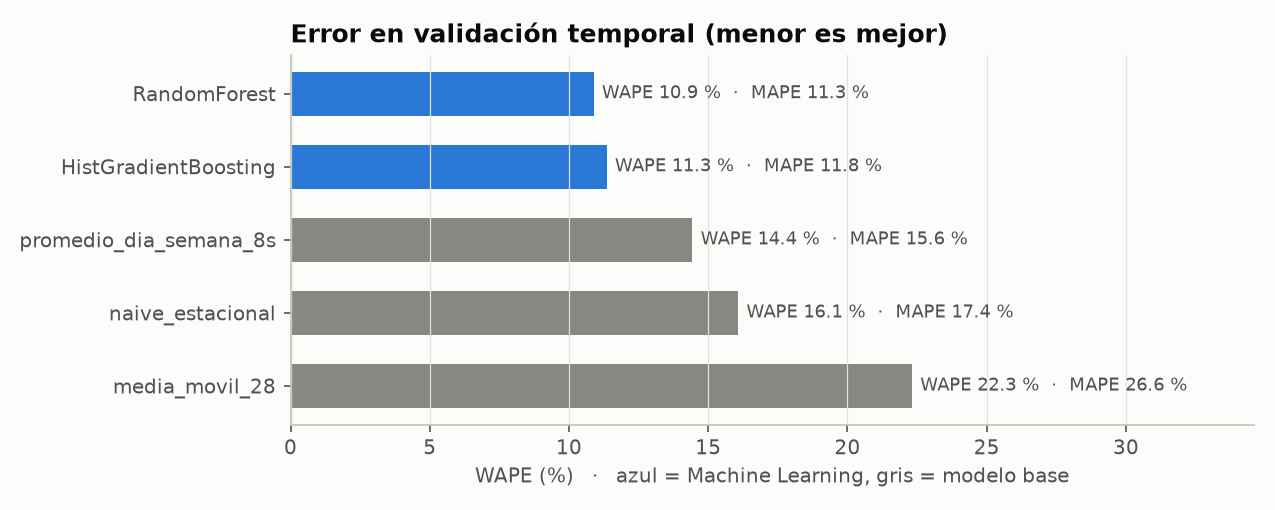

In [8]:
figures.comparacion_modelos(metricas, ["RandomForest", "HistGradientBoosting"])
Image(figures.FIGURES / "03_comparacion_modelos.png")

In [9]:
mejor, base = metricas.iloc[0]["modelo"], "promedio_dia_semana_8s"
w = metricas.set_index("modelo")["WAPE"]
print(f"Mejor modelo: {mejor} (WAPE {w[mejor]:.1f} %)")
print(f"Mejor modelo base: {base} (WAPE {w[base]:.1f} %)")
print(f"Reducción del error: {(w[base] - w[mejor]) / w[base] * 100:.1f} %")

Mejor modelo: RandomForest (WAPE 10.9 %)
Mejor modelo base: promedio_dia_semana_8s (WAPE 14.4 %)
Reducción del error: 24.6 %


### Estabilidad por fold: ¿el modelo gana siempre o solo en promedio?

In [10]:
metricas_por_grupo(bt, ["modelo", "fold"]).pivot(index="modelo", columns="fold", values="WAPE").round(1)

fold,1,2,3,4
modelo,,,,
HistGradientBoosting,10.0,11.0,13.1,11.2
RandomForest,10.0,10.7,12.0,10.6
media_movil_28,21.0,20.4,20.4,28.7
naive_estacional,13.1,14.3,15.5,22.5
promedio_dia_semana_8s,10.5,11.3,12.6,25.3


El ML gana en los 4 folds. Nótese el **fold 4 (diciembre)**: los modelos base empeoran mucho (WAPE 22-29 %) porque copian el nivel de noviembre y no saben que en diciembre la demanda cae. El ML sí lo anticipa gracias a `lag_364` (mismo día del año anterior) y variables de calendario.

### Precisión semanal
Para reabastecer importa más el total de la semana que el de cada día. Al agregar, los errores diarios se compensan parcialmente:

In [11]:
semanal = (bt.assign(semana=bt["fecha"].dt.to_period("W").dt.start_time)
           .groupby(["modelo", "fold", "semana", "producto_id", "ubicacion_id"], as_index=False)[["y", "yhat"]].sum())
metricas_por_grupo(semanal, ["modelo"]).sort_values("WAPE").round(2)

,modelo,MAE,MAPE,WAPE,Sesgo_pct,RMSE,n
1,RandomForest,7.14,5.76,5.52,0.82,10.69,1500
0,HistGradientBoosting,8.46,6.76,6.53,1.50,12.62,1500
3,naive_estacional,11.51,10.36,8.89,3.21,17.30,1500
4,promedio_dia_semana_8s,13.42,11.75,10.37,2.42,20.44,1500
2,media_movil_28,14.39,12.78,11.12,3.58,22.15,1500


### Precisión por producto (mejor modelo vs. mejor base)

In [12]:
pp = metricas_por_grupo(bt[bt["modelo"].isin([mejor, base])], ["producto_id", "modelo"])
pp.pivot(index="producto_id", columns="modelo", values="WAPE").round(1).assign(
    mejora_pct=lambda d: ((d[base] - d[mejor]) / d[base] * 100).round(1)).sort_values("mejora_pct", ascending=False)

modelo,RandomForest,promedio_dia_semana_8s,mejora_pct
producto_id,,,
MED-001,10.1,14.9,32.2
MED-004,10.6,15.3,30.7
MED-011,10.6,14.9,28.9
MED-005,10.8,14.7,26.5
MED-009,10.8,14.6,26.0
MED-014,11.0,14.7,25.2
MED-007,10.7,14.0,23.6
MED-012,11.3,14.8,23.6
MED-013,11.4,14.7,22.4


## 4. ¿Qué aprendió el modelo? Importancia por permutación

Técnica: se "desordena" una variable a la vez y se mide cuánto empeora el MAE. Si empeora mucho, el modelo depende de esa variable. (Se calcula en `run_pipeline.py` sobre el último fold.)

In [13]:
pd.read_csv(DATA_PROCESSED / "importancia_variables.csv").round(3).head(10)

,variable,aumento_mae
0,prom_dia_semana_4s,4.441
1,media_movil_91,0.779
2,lag_49,0.565
3,lag_364,0.324
4,lag_42,0.215
5,dia_semana,0.063
6,media_movil_28,0.062
7,lag_28,0.054
8,lag_35,0.033
9,fin_de_semana,0.032


- `prom_dia_semana_4s` (promedio de los últimos 4 mismos-días-de-la-semana) domina: captura el **nivel reciente** y el **patrón semanal** a la vez.
- `media_movil_91` aporta el nivel de mediano plazo; `lag_364` la **estacionalidad anual** (clave en diciembre).
- Las variables de calendario suman poco *por separado* porque su información ya está dentro de los rezagos semanales.

## 5. Pronóstico final (enero 2026) con intervalo

El modelo ganador se **reentrena con toda la historia** y pronostica 28 días. El intervalo 80 % es empírico: se suman los percentiles 10 y 90 de los errores observados en el backtest de cada serie.

In [14]:
futuro = pd.read_csv(DATA_PROCESSED / "pronostico_futuro.csv", parse_dates=["fecha"])
futuro.head(8).round({"yhat": 1, "yhat_inf": 1, "yhat_sup": 1})

,fecha,producto_id,ubicacion_id,yhat,yhat_inf,yhat_sup,modelo
0,2026-01-01,MED-001,LOC-001,78.4,66.3,90.8,RandomForest
1,2026-01-02,MED-001,LOC-001,78.1,66.0,90.5,RandomForest
2,2026-01-03,MED-001,LOC-001,49.2,37.1,61.6,RandomForest
3,2026-01-04,MED-001,LOC-001,47.1,35.0,59.5,RandomForest
4,2026-01-05,MED-001,LOC-001,83.4,71.3,95.8,RandomForest
5,2026-01-06,MED-001,LOC-001,80.9,68.8,93.3,RandomForest
6,2026-01-07,MED-001,LOC-001,79.3,67.2,91.7,RandomForest
7,2026-01-08,MED-001,LOC-001,77.6,65.5,90.0,RandomForest


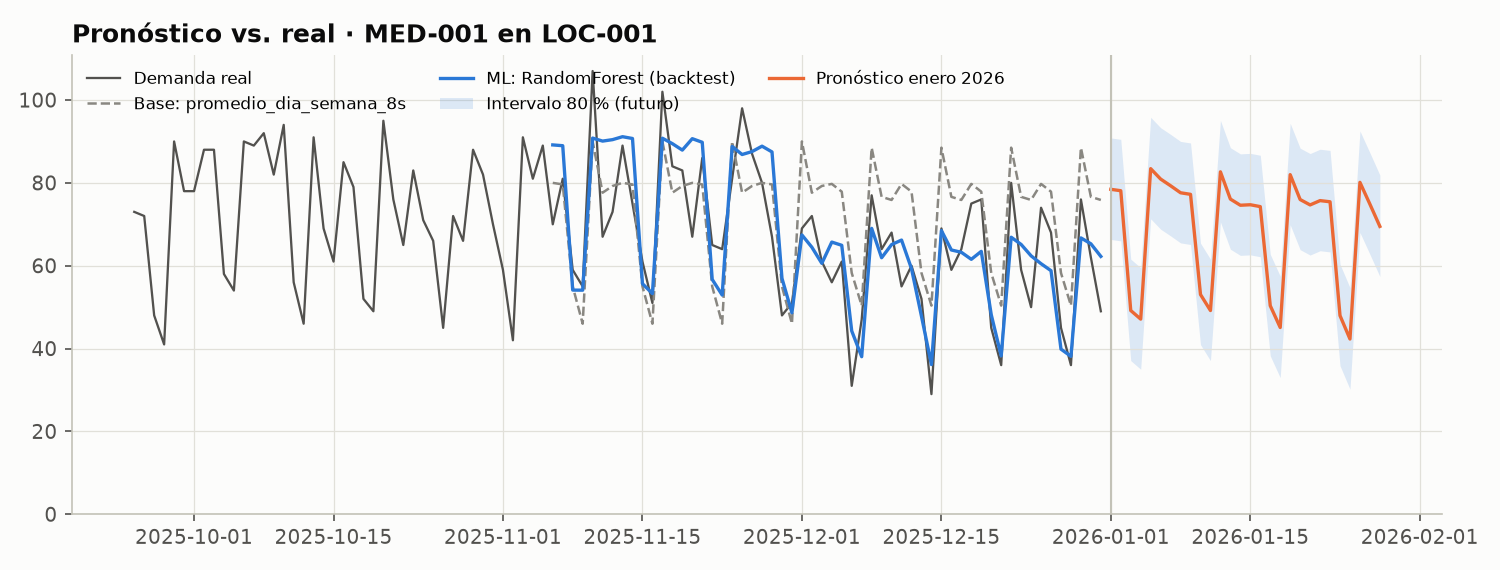

In [15]:
Image(figures.FIGURES / "04_pronostico_ejemplo.png")

In [16]:
resumen = futuro.groupby("producto_id")[["yhat", "yhat_inf", "yhat_sup"]].sum().round(0)
resumen.columns = ["pronostico_28d", "limite_inferior", "limite_superior"]
resumen

,pronostico_28d,limite_inferior,limite_superior
producto_id,,,
MED-001,6473.0,5508.0,7536.0
MED-002,5582.0,4495.0,6526.0
MED-003,4392.0,3617.0,5118.0
MED-004,3497.0,2881.0,4040.0
MED-005,1320.0,1077.0,1521.0
MED-006,1169.0,952.0,1356.0
MED-007,4638.0,3875.0,5379.0
MED-008,2208.0,1752.0,2536.0
MED-009,5787.0,4869.0,6759.0


## Conclusiones y limitaciones

- El Machine Learning (**RandomForest**) reduce el WAPE **~25 %** frente al mejor modelo base, con sesgo cercano a 0 → no infla ni subestima sistemáticamente.
- La ganancia es mayor en periodos atípicos (diciembre), justo donde las reglas simples fallan.
- **Limitaciones:** los datos son sintéticos; no hay variables externas (epidemias, calendario de cirugías, festivos colombianos); el intervalo empírico asume que los errores futuros se parecen a los del backtest.
- **Próximos pasos:** agregar festivos, probar LightGBM y modelos jerárquicos, y reentrenar mensualmente monitoreando el WAPE (MLOps).

➡️ Siguiente: `03_politica_inventario_y_alertas.ipynb`